# Understanding the data: shape, channels, and how to index them

This notebook answers one question: **what is actually inside one of these files, and how do
I get at a single channel?**

Everything below runs on the real release in `competition_release/`. Nothing is assumed —
every claim is printed out so you can check it.

**Contents**

1. `.npy` vs `.npz` — why `np.load` doesn't hand you an array
2. Reading the shape
3. One pixel is a vector of 8 numbers
4. The `[:][:]` trap
5. Ways to grab a single channel
6. Accessing channels by *name* instead of by number
7. Per-band statistics (and why the scales matter)
8. Looking at all 8 channels
9. An RGB composite
10. Chip sizes are not all the same
11. One label mask, overlaid
12. HWC vs CHW — the conversion you'll need for PyTorch

In [1]:
from pathlib import Path
import json
import csv

import numpy as np
import matplotlib.pyplot as plt

# Everything is resolved from this one constant, so the notebook works from the repo root.
RELEASE = Path("competition_release")
CHIP = RELEASE / "train" / "images" / "train_000001.npz"

print("release exists:", RELEASE.is_dir())
print("chip exists:   ", CHIP.is_file())
print("numpy:", np.__version__)

release exists: True
chip exists:    True
numpy: 2.5.2


---
## 1. `.npy` vs `.npz` — why `np.load` doesn't hand you an array

This is the whole source of the confusion, and it is worth being precise about:

| | what it is | what `np.load` returns |
|---|---|---|
| `.npy` | **one** array, raw | the `ndarray` itself |
| `.npz` | a **zip archive** holding one or more *named* arrays | an `NpzFile` — a lazy, dict-like object |

The files in this release are **`.npz`**, so `np.load(...)` gives you a container, not an
image. You still have to ask it for the array by key. That is why printing the result of
`np.load` shows `NpzFile ... with keys: image` rather than a grid of numbers.

`.files` lists the keys inside. Here there is exactly one: `"image"`.

In [2]:
data = np.load(CHIP)

print("type of np.load(...) ->", type(data).__name__)
print("keys inside the zip  ->", data.files)

img = data["image"]          # <- this is the actual array
print("type of data['image'] ->", type(img).__name__)

type of np.load(...) -> NpzFile
keys inside the zip  -> ['image']
type of data['image'] -> ndarray


An `NpzFile` is an **open file handle**. In a one-off cell that does not matter, but when you
loop over all 756 chips, leaving handles open will eventually bite you. Use a `with` block —
the same pattern the organisers use in `competition_release/examples/load_image_and_label.py`:

In [3]:
with np.load(CHIP) as data:
    img = data["image"]      # pulled out of the zip while the handle is open

print("loaded and closed cleanly:", img.shape)

loaded and closed cleanly: (159, 289, 8)


---
## 2. Reading the shape

`img.shape` is a tuple with one entry per axis. Here it has three entries, and the release
metadata (`metadata/band_names.json`, field `"axis_order"`) tells us the order is **HWC**:

```
        (159,      289,       8)
          |         |         |
          H         W         C
        rows     columns   channels
   (north-south) (east-west)  (bands)
```

So this chip is 159 pixels tall, 289 pixels wide, and every pixel carries 8 measurements.

In [4]:
print("shape :", img.shape)
print("ndim  :", img.ndim, "  (number of axes)")
print("dtype :", img.dtype)
print("size  :", img.size, "  (total numbers = H*W*C)")
print("bytes :", img.nbytes)

H, W, C = img.shape                      # unpack it explicitly - do this everywhere
print()
print(f"H (height / rows)     = {H}")
print(f"W (width / columns)   = {W}")
print(f"C (channels / bands)  = {C}")
print("H * W * C =", H * W * C, " == img.size:", H * W * C == img.size)

shape : (159, 289, 8)
ndim  : 3   (number of axes)
dtype : float32
size  : 367608   (total numbers = H*W*C)
bytes : 1470432

H (height / rows)     = 159
W (width / columns)   = 289
C (channels / bands)  = 8
H * W * C = 367608  == img.size: True


Note that `dtype` is `float32` even though the red/green/blue bands hold whole numbers like
`89.0`. Everything was cast to one float type so all 8 bands could share a single array.

---
## 3. One pixel is a vector of 8 numbers

The clearest mental model: this is **not** an image with a channel axis bolted on. It is a
**grid of measurements**, where each grid cell holds 8 numbers.

- `img[row, col]` -> the 8 numbers at that pixel, shape `(8,)`
- `img[row, col, band]` -> a single number, a scalar

In [5]:
row, col = 80, 140

pixel = img[row, col]
print("img[80, 140]      ->", pixel)
print("its shape         ->", pixel.shape, " (8 numbers = one per band)")
print()
print("img[80, 140, 0]   ->", img[row, col, 0], "  (just the red value, a scalar)")
print("img[80, 140, 6]   ->", img[row, col, 6], "  (just the NIR value)")

img[80, 140]      -> [ 1.1300000e+02  1.0800000e+02  8.9000000e+01  6.4359114e-02
 -8.1469727e-01  1.6831023e+02  1.6340000e+03 -1.6725978e-01]
its shape         -> (8,)  (8 numbers = one per band)

img[80, 140, 0]   -> 113.0   (just the red value, a scalar)
img[80, 140, 6]   -> 1634.0   (just the NIR value)


---
## 4. The `[:][:]` trap

This one is worth burning in, because it produces *wrong answers silently* rather than errors.

**Chained brackets index the same axis over and over.** `img[:]` returns the whole array
(a view along axis 0). Applying `[:]` to *that* result... still returns the whole array. It
never moves on to the second axis.

**Commas inside a single bracket** are what select across different axes.

Likewise `len(img)` is *always* `img.shape[0]` — it only knows about axis 0. That is why
`len(img)` prints `159` and `len(img[0][0])` prints `8`: the second walked down two axes, one
bracket at a time, to land on the channel axis.

In [6]:
print("img[:].shape        ->", img[:].shape,        "  <- unchanged")
print("img[:][:].shape     ->", img[:][:].shape,     "  <- STILL unchanged, not the 2nd axis!")
print("img[:][:][:].shape  ->", img[:][:][:].shape,  "  <- still nothing happened")
print()
print("img[:, :, 0].shape  ->", img[:, :, 0].shape,  "  <- THIS is channel 0")
print("img[:, 0, :].shape  ->", img[:, 0, :].shape,  "  <- one column, all 8 bands")
print("img[0, :, :].shape  ->", img[0, :, :].shape,  "  <- one row, all 8 bands")
print()
print("len(img)         ->", len(img),         " == img.shape[0]")
print("len(img[0])      ->", len(img[0]),      " == img.shape[1]")
print("len(img[0][0])   ->", len(img[0][0]),   " == img.shape[2]")

img[:].shape        -> (159, 289, 8)   <- unchanged
img[:][:].shape     -> (159, 289, 8)   <- STILL unchanged, not the 2nd axis!
img[:][:][:].shape  -> (159, 289, 8)   <- still nothing happened

img[:, :, 0].shape  -> (159, 289)   <- THIS is channel 0
img[:, 0, :].shape  -> (159, 8)   <- one column, all 8 bands
img[0, :, :].shape  -> (289, 8)   <- one row, all 8 bands

len(img)         -> 159  == img.shape[0]
len(img[0])      -> 289  == img.shape[1]
len(img[0][0])   -> 8  == img.shape[2]


**Rule of thumb:** never use `len()` to inspect a numpy array — it answers a question about
one axis and stays silent about the rest. Use `.shape`, which tells you everything at once.

---
## 5. Ways to grab a single channel

These are all equivalent ways to pull out band 3 (`ndvi`). The second is the idiomatic one.

In [7]:
a = img[:, :, 3]            # explicit: all rows, all columns, band 3
b = img[..., 3]             # `...` means "all remaining leading axes" - most idiomatic
c = img.take(3, axis=-1)    # by axis number, reads well in generic code
d = np.dsplit(img, 8)[3]    # split into 8 pieces along the depth axis (keeps a trailing 1)

print("img[:, :, 3]      ->", a.shape)
print("img[..., 3]       ->", b.shape)
print("img.take(3, -1)   ->", c.shape)
print("np.dsplit(...)[3] ->", d.shape, " <- trailing 1; use .squeeze() to drop it")
print()
print("all identical:",
      np.array_equal(a, b, equal_nan=True) and np.array_equal(a, c, equal_nan=True))

img[:, :, 3]      -> (159, 289)
img[..., 3]       -> (159, 289)
img.take(3, -1)   -> (159, 289)
np.dsplit(...)[3] -> (159, 289, 1)  <- trailing 1; use .squeeze() to drop it

all identical: True


### Views vs copies — the one gotcha

Basic slicing (`img[..., 3]`) returns a **view**: it shares memory with `img`, so writing into
it writes into the original. Fancy indexing with a *list* (`img[..., [0, 1, 2]]`) returns a
**copy**. When in doubt and you intend to modify, call `.copy()`.

In [8]:
print("img[..., 3] shares memory with img?   ", np.shares_memory(img[..., 3], img))
print("img[..., [3]] shares memory with img? ", np.shares_memory(img[..., [3]], img))
print()
print("img[..., 0:3]     -> view? ", np.shares_memory(img[..., 0:3], img), " (slice -> view)")
print("img[..., [0,1,2]] -> view? ", np.shares_memory(img[..., [0, 1, 2]], img), " (list -> copy)")

img[..., 3] shares memory with img?    True
img[..., [3]] shares memory with img?  False

img[..., 0:3]     -> view?  True  (slice -> view)
img[..., [0,1,2]] -> view?  False  (list -> copy)


---
## 6. Accessing channels by *name* instead of by number

Hardcoding `img[..., 3]` works right up until the band order changes, and then it fails
silently with plausible-looking numbers. `metadata/band_names.json` is the source of truth —
read the mapping from it.

In [9]:
band_meta = json.loads((RELEASE / "metadata" / "band_names.json").read_text())

print("axis_order:", band_meta["axis_order"])
print("array_key :", band_meta["array_key"])
print()

BAND_NAMES = [b["name"] for b in band_meta["bands"]]
BAND_INDEX = {b["name"]: b["index"] for b in band_meta["bands"]}

for b in band_meta["bands"]:
    print(f"  {b['index']}  {b['name']:<20} {b['source']}")


def band(image, name):
    '''Return one channel of an HWC image by band name, e.g. band(img, "ndvi").'''
    return image[..., BAND_INDEX[name]]

axis_order: HWC
array_key : image

  0  red                  Maxar red
  1  green                Maxar green
  2  blue                 Maxar blue
  3  ndvi                 Normalized Difference Vegetation Index
  4  relative_elevation   Relative elevation
  5  shaded_relief        Shaded relief
  6  nir                  Planet near-infrared
  7  ndwi                 Normalized Difference Water Index


In [10]:
ndvi = band(img, "ndvi")
nir = band(img, "nir")

print("band(img, 'ndvi').shape ->", ndvi.shape)
print("band(img, 'nir').shape  ->", nir.shape)
print("identical to img[..., 3]:", np.array_equal(ndvi, img[..., 3], equal_nan=True))

band(img, 'ndvi').shape -> (159, 289)
band(img, 'nir').shape  -> (159, 289)
identical to img[..., 3]: True


---
## 7. Per-band statistics (and why the scales matter)

Three things to notice in the table below.

1. **The bands are on wildly different numeric scales.** RGB sit in `0..255`, NIR is in the
   thousands, NDVI and NDWI are small signed fractions, relative elevation is signed metres.
   Anything that mixes them arithmetically needs per-band normalisation first.
2. **There are NaNs.** That is why every statistic below uses the `np.nan*` variants — plain
   `.min()` / `.mean()` would return `nan` and poison the result.
3. The array is `float32` even where the values are integer-valued digital numbers.

In [11]:
print(f"{'idx':<4}{'name':<20}{'min':>12}{'max':>12}{'mean':>12}{'std':>10}{'NaNs':>8}")
print("-" * 78)
for i, name in enumerate(BAND_NAMES):
    b = img[..., i]
    print(f"{i:<4}{name:<20}"
          f"{np.nanmin(b):>12.3f}{np.nanmax(b):>12.3f}"
          f"{np.nanmean(b):>12.3f}{np.nanstd(b):>10.3f}"
          f"{int(np.isnan(b).sum()):>8}")
print("-" * 78)
print(f"total NaNs in this chip: {int(np.isnan(img).sum())} of {img.size} values")

idx name                         min         max        mean       std    NaNs
------------------------------------------------------------------------------
0   red                        1.000     229.000     138.273    39.980      53
1   green                      1.000     217.000     129.043    36.431      53
2   blue                       1.000     195.000     109.605    31.897      93
3   ndvi                      -0.034       0.445       0.100     0.058       0
4   relative_elevation        -9.185       7.570       0.011     0.899       0
5   shaded_relief            142.941     187.291     170.217     8.344       0
6   nir                      740.500    1997.000    1573.767   184.516       0
7   ndwi                      -0.518       0.051      -0.211     0.059       0
------------------------------------------------------------------------------
total NaNs in this chip: 199 of 367608 values


In [12]:
# What plain, non-nan-aware statistics would have given you:
print("np.min(img[..., 0])    ->", np.min(img[..., 0]), "  <- poisoned by NaN")
print("np.nanmin(img[..., 0]) ->", np.nanmin(img[..., 0]), "  <- correct")

np.min(img[..., 0])    -> nan   <- poisoned by NaN
np.nanmin(img[..., 0]) -> 1.0   <- correct


---
## 8. Looking at all 8 channels

Each panel is one `(H, W)` slice. Because the bands live on different scales, each is
stretched to its own 2nd-98th percentile — otherwise a single outlier washes the panel out.
`imshow` draws NaNs as blank, so any speckling is missing data.

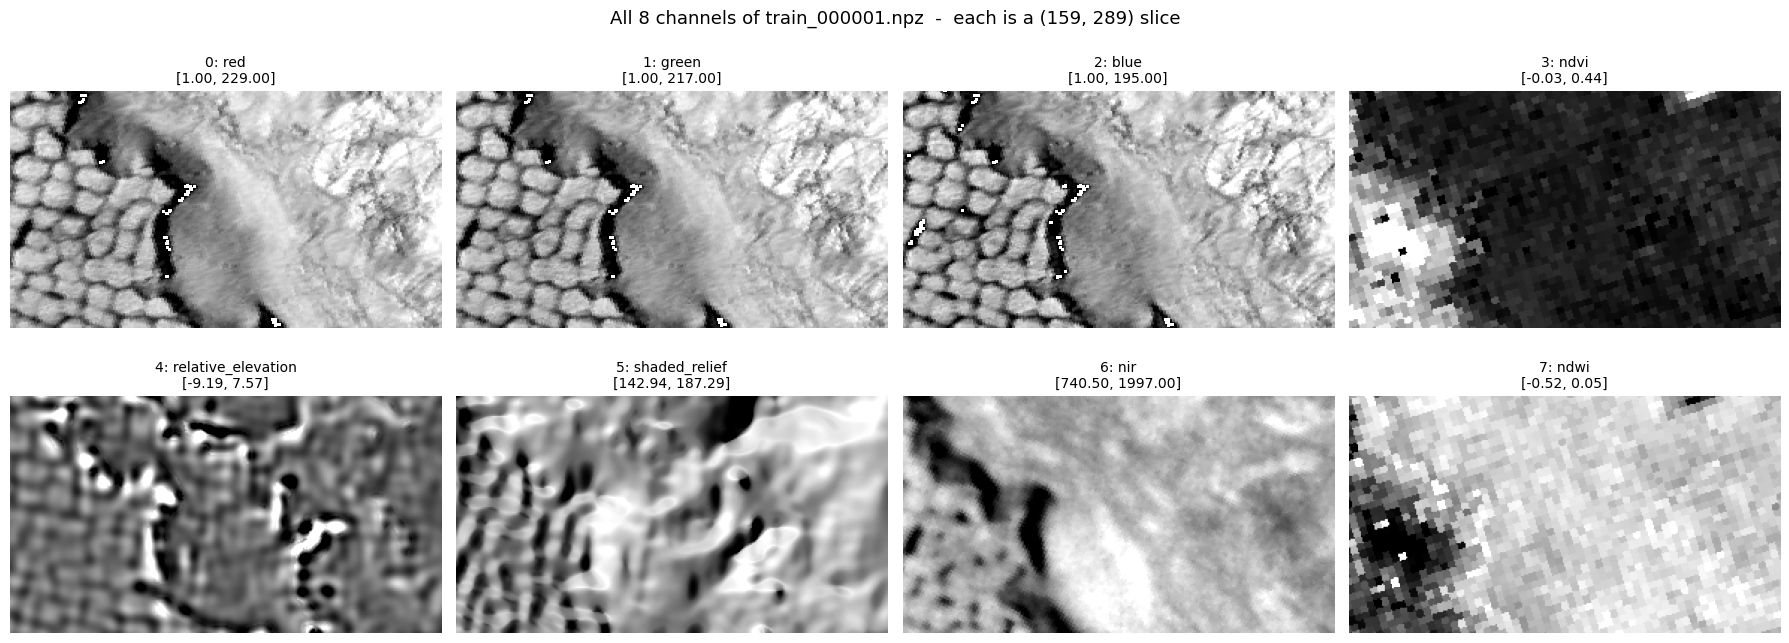

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))

for i, ax in enumerate(axes.ravel()):
    b = img[..., i]
    vmin, vmax = np.nanpercentile(b, [2, 98])
    ax.imshow(b, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(f"{i}: {BAND_NAMES[i]}\n[{np.nanmin(b):.2f}, {np.nanmax(b):.2f}]", fontsize=10)
    ax.axis("off")

fig.suptitle(
    f"All 8 channels of {CHIP.name}  -  each is a ({img.shape[0]}, {img.shape[1]}) slice",
    fontsize=13,
)
fig.tight_layout()
plt.show()

---
## 9. An RGB composite

Bands 0, 1, 2 are red, green and blue, so stacking those three gives a natural-colour image.
Two details:

- `img[..., [0, 1, 2]]` uses a **list**, so it returns a copy — fine here, we modify it anyway.
- The raw values need a **contrast stretch** into `[0, 1]` before `imshow` shows anything
  useful. Matplotlib clips float RGB data to `[0, 1]`, so feeding it raw `0..229` values
  produces an almost entirely white image.

rgb_raw.shape: (159, 289, 3)  range: 1.0 - 229.0
rgb.shape    : (159, 289, 3)  range: 0.0 - 1.0


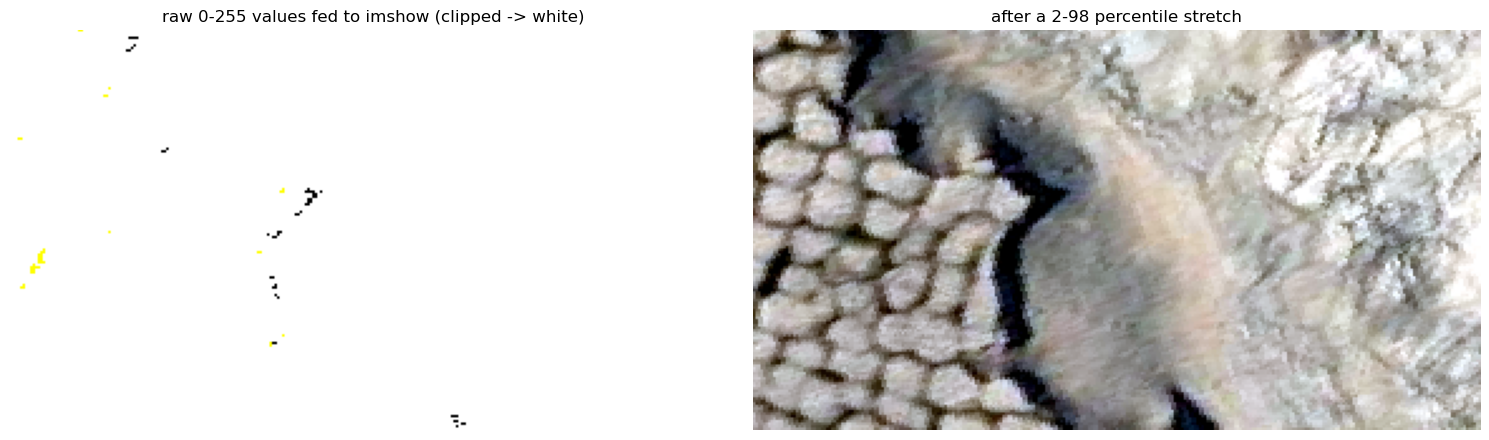

In [14]:
def stretch(a, lo=2, hi=98):
    '''Percentile-stretch each channel of an HWC array into [0, 1]; NaNs become 0.'''
    out = np.zeros(a.shape, dtype=np.float32)
    for i in range(a.shape[-1]):
        ch = a[..., i]
        vmin, vmax = np.nanpercentile(ch, [lo, hi])
        scaled = (ch - vmin) / (vmax - vmin + 1e-8)
        out[..., i] = np.nan_to_num(np.clip(scaled, 0, 1), nan=0.0)
    return out


rgb_raw = img[..., [0, 1, 2]]        # red, green, blue
rgb = stretch(rgb_raw)

print("rgb_raw.shape:", rgb_raw.shape,
      " range:", float(np.nanmin(rgb_raw)), "-", float(np.nanmax(rgb_raw)))
print("rgb.shape    :", rgb.shape,
      " range:", float(rgb.min()), "-", float(rgb.max()))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.imshow(np.clip(np.nan_to_num(rgb_raw), 0, 1))
ax1.set_title("raw 0-255 values fed to imshow (clipped -> white)")
ax1.axis("off")
ax2.imshow(rgb)
ax2.set_title("after a 2-98 percentile stretch")
ax2.axis("off")
plt.tight_layout()
plt.show()

---
## 10. Chip sizes are not all the same

`train_000001` is `159 x 289`, but that is **not** a fixed size — H and W vary chip to chip.
Only `C = 8` is constant. `metadata/train_manifest.csv` lists the dimensions of every chip
without having to open the arrays.

This matters as soon as you batch: you will need padding, cropping or resizing, and you must
never hardcode `159` or `289`.

In [15]:
with open(RELEASE / "metadata" / "train_manifest.csv", newline="") as f:
    rows = list(csv.DictReader(f))

print("columns:", list(rows[0].keys()))
print("chips  :", len(rows))
print()
for r in rows[:5]:
    print(f"  {r['public_id']}  {r['width']} x {r['height']}   {r['file_name']}")

widths = np.array([int(r["width"]) for r in rows])
heights = np.array([int(r["height"]) for r in rows])

print()
print(f"width  : min {widths.min():>4}  max {widths.max():>4}  "
      f"{len(np.unique(widths))} distinct values")
print(f"height : min {heights.min():>4}  max {heights.max():>4}  "
      f"{len(np.unique(heights))} distinct values")
print(f"distinct (w, h) pairs: {len(set(zip(widths.tolist(), heights.tolist())))}")

columns: ['split', 'public_id', 'image_id', 'file_name', 'width', 'height']
chips  : 756

  train_000001  289 x 159   train/images/train_000001.npz
  train_000002  289 x 158   train/images/train_000002.npz
  train_000003  291 x 137   train/images/train_000003.npz
  train_000004  291 x 136   train/images/train_000004.npz
  train_000005  289 x 158   train/images/train_000005.npz

width  : min  150  max  297  19 distinct values
height : min  106  max  295  39 distinct values
distinct (w, h) pairs: 87


---
## 11. One label mask, overlaid

Labels live in a single COCO-format file, `train/annotations/instances_train.json`, with one
category (`rts`). Masks are stored **RLE-encoded** and decoded with `pycocotools`.

The key shape fact: a decoded mask is `(H, W)` `uint8` of 0s and 1s — **the same H and W as
the image, with no channel axis**. And there is **one mask per RTS instance**, not one per
image, so a chip with three slumps has three masks.

In [16]:
from pycocotools import mask as mask_utils

coco = json.loads((RELEASE / "train" / "annotations" / "instances_train.json").read_text())

print("top-level keys :", list(coco.keys()))
print("categories     :", coco["categories"])
print("images         :", len(coco["images"]))
print("annotations    :", len(coco["annotations"]))

top-level keys : ['info', 'licenses', 'categories', 'images', 'annotations']
categories     : [{'id': 1, 'name': 'rts', 'supercategory': 'landform'}]
images         : 756
annotations    : 1783


One wrinkle worth knowing before you join these tables: the `file_name` in the COCO file is
`images/train_000001.npz`, while `metadata/train_manifest.csv` writes the same chip as
`train/images/train_000001.npz`. The prefixes differ, so match on the **basename**, not on the
full string.

In [17]:
# Find the record for our chip, then its annotations. Match on basename - see the note above.
record = next(r for r in coco["images"] if Path(r["file_name"]).name == CHIP.name)
anns = [a for a in coco["annotations"] if a["image_id"] == record["id"]]

print("image record :", {k: record[k] for k in ("id", "file_name", "width", "height")})
print("instances    :", len(anns))
print()

masks = [mask_utils.decode(a["segmentation"]) for a in anns]
for a, m in zip(anns, masks):
    print(f"  ann {a['id']:>5}  bbox={a['bbox']}  mask.shape={m.shape}  "
          f"dtype={m.dtype}  unique={np.unique(m)}  pixels={int(m.sum())}")

print()
print("image is (H, W, C) =", img.shape)
print("mask  is (H, W)    =", masks[0].shape,
      " -> same H and W, no channel axis:", masks[0].shape == img.shape[:2])

image record : {'id': 1, 'file_name': 'images/train_000001.npz', 'width': 289, 'height': 159}
instances    : 1

  ann     1  bbox=[45, 0, 234, 159]  mask.shape=(159, 289)  dtype=uint8  unique=[0 1]  pixels=21105

image is (H, W, C) = (159, 289, 8)
mask  is (H, W)    = (159, 289)  -> same H and W, no channel axis: True


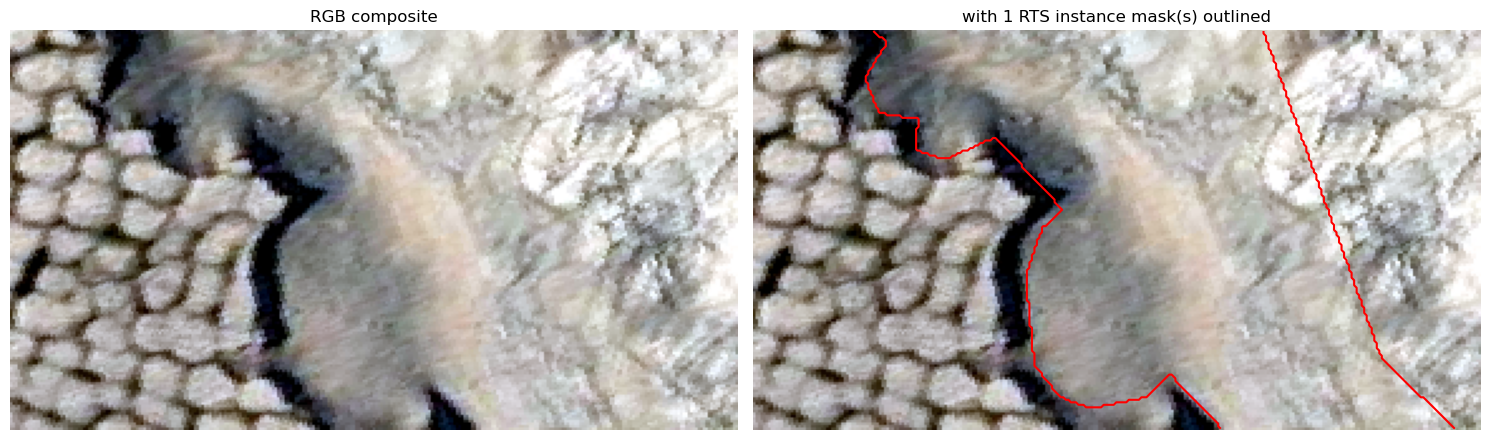

In [18]:
union = np.zeros(img.shape[:2], dtype=np.uint8)
for m in masks:
    union |= m

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.imshow(rgb)
ax1.set_title("RGB composite")
ax1.axis("off")
ax2.imshow(rgb)
ax2.contour(union, levels=[0.5], colors="red", linewidths=1.5)
ax2.set_title(f"with {len(masks)} RTS instance mask(s) outlined")
ax2.axis("off")
plt.tight_layout()
plt.show()

---
## 12. HWC vs CHW — the conversion you will need for PyTorch

Two conventions exist for where the channel axis goes, and both are common:

- **HWC** `(159, 289, 8)` — what these files use, and what `matplotlib.imshow` expects.
- **CHW** `(8, 159, 289)` — what PyTorch conv layers expect.

`np.transpose` reorders the axes. Get this wrong and you do not get an error — you get a model
quietly training on an array it believes has 159 channels.

In [19]:
chw = np.transpose(img, (2, 0, 1))     # (H, W, C) -> (C, H, W)

print("HWC (on disk, matplotlib) :", img.shape)
print("CHW (PyTorch)             :", chw.shape)
print()
print("same data?", np.array_equal(chw[3], img[..., 3], equal_nan=True))
print("transpose is a view (free):", np.shares_memory(chw, img))
print("...but not contiguous:", chw.flags["C_CONTIGUOUS"],
      "-> wrap in np.ascontiguousarray for torch")

# import torch
# tensor = torch.from_numpy(np.ascontiguousarray(chw))   # -> torch.Size([8, 159, 289])
# batch  = tensor.unsqueeze(0)                           # -> torch.Size([1, 8, 159, 289])

HWC (on disk, matplotlib) : (159, 289, 8)
CHW (PyTorch)             : (8, 159, 289)

same data? True
transpose is a view (free): True
...but not contiguous: False -> wrap in np.ascontiguousarray for torch


---
## Summary

| question | answer |
|---|---|
| file format | `.npz` — a **zip of named arrays**, not a bare `.npy` array |
| how to get the array | `with np.load(path) as d: img = d["image"]` |
| shape | `(H, W, 8)` — **HWC**; H and W vary per chip, C is always 8 |
| dtype | `float32`, and it **contains NaNs** — use `np.nanmin` / `np.nanmean` / ... |
| one pixel | `img[r, c]` -> a vector of 8 numbers |
| one channel | `img[..., i]` — commas in **one** bracket, never `img[:][:]` |
| channel by name | `img[..., BAND_INDEX["ndvi"]]`, from `metadata/band_names.json` |
| band order | `0 red, 1 green, 2 blue, 3 ndvi, 4 relative_elevation, 5 shaded_relief, 6 nir, 7 ndwi` |
| scales | totally different per band — normalise before combining |
| labels | COCO RLE, one `(H, W)` uint8 mask **per instance** |
| for PyTorch | `np.transpose(img, (2, 0, 1))` -> CHW |